In [7]:
import warnings
warnings.filterwarnings('ignore')
!pip install vaderSentiment gensim pyLDAvis -q
import requests, time, pandas as pd


In [10]:
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

import os, json, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
JSON_FOLDER = '/content/drive/MyDrive/Final Project/Data reviews'

all_reviews = []

for filename in os.listdir(JSON_FOLDER):
    if not filename.endswith('.json'):
        continue
    filepath = os.path.join(JSON_FOLDER, filename)
    with open(filepath, 'r') as f:
        data = json.load(f)
    if isinstance(data, list):
        reviews = data
    elif isinstance(data, dict):
        reviews = data.get('reviews', data.get('data', []))
    shop_name = filename.replace('.json', '').strip()
    for rev in reviews:
        rev['business_name'] = shop_name
    all_reviews.extend(reviews)

df = pd.DataFrame(all_reviews)

In [13]:
import re
df['business_name'] = df['business_name'].str.replace(r'\s*\(\d+\)$', '', regex=True).str.strip()

print(f"✅ Total reviews: {len(df)}")
print(f"✅ Unique shops: {df['business_name'].nunique()}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nRating distribution:\n{df['rating'].value_counts().sort_index()}")

✅ Total reviews: 11022
✅ Unique shops: 32
Columns: ['id', 'url', 'text', 'edits', 'author', 'photos', 'rating', 'replies', 'editedAt', 'isHidden', 'language', 'replyUrl', 'isDeleted', 'timestamp', 'translation', 'recommendation', 'business_name']

Rating distribution:
rating
1     539
2     117
3     116
4     468
5    9782
Name: count, dtype: int64


In [14]:
analyzer = SentimentIntensityAnalyzer()
df['review_length'] = df['text'].apply(lambda x: len(str(x).split()))
df['sentiment_score'] = df['text'].apply(lambda x: analyzer.polarity_scores(str(x))['compound'])
print(df[['rating', 'review_length', 'sentiment_score']].describe())


             rating  review_length  sentiment_score
count  11022.000000   11022.000000     11022.000000
mean       4.709036      92.636454         0.719048
std        0.936990      85.101355         0.428680
min        1.000000       1.000000        -0.997900
25%        5.000000      38.000000         0.717700
50%        5.000000      68.000000         0.894700
75%        5.000000     118.000000         0.954875
max        5.000000     957.000000         0.999300


In [15]:
df.to_csv('/content/drive/MyDrive/Final Project/reviews_clean.csv', index=False)
print("Clean data saved to Drive!")

Clean data saved to Drive!


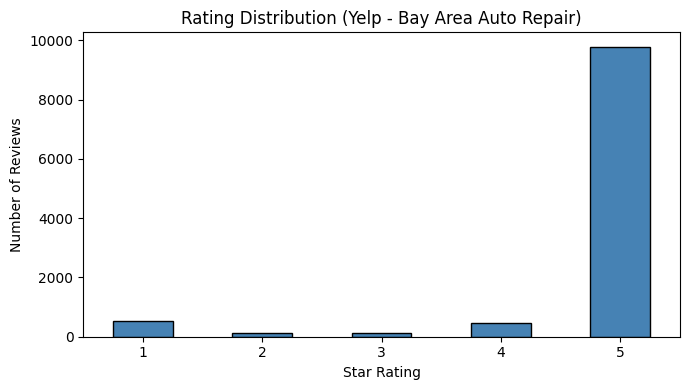

In [23]:
plt.figure(figsize=(7,4))
df['rating'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Rating Distribution (Yelp - Bay Area Auto Repair)')
plt.xlabel('Star Rating')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Final Project/Visualizations/rating_distribution.png', dpi=150)

plt.show()

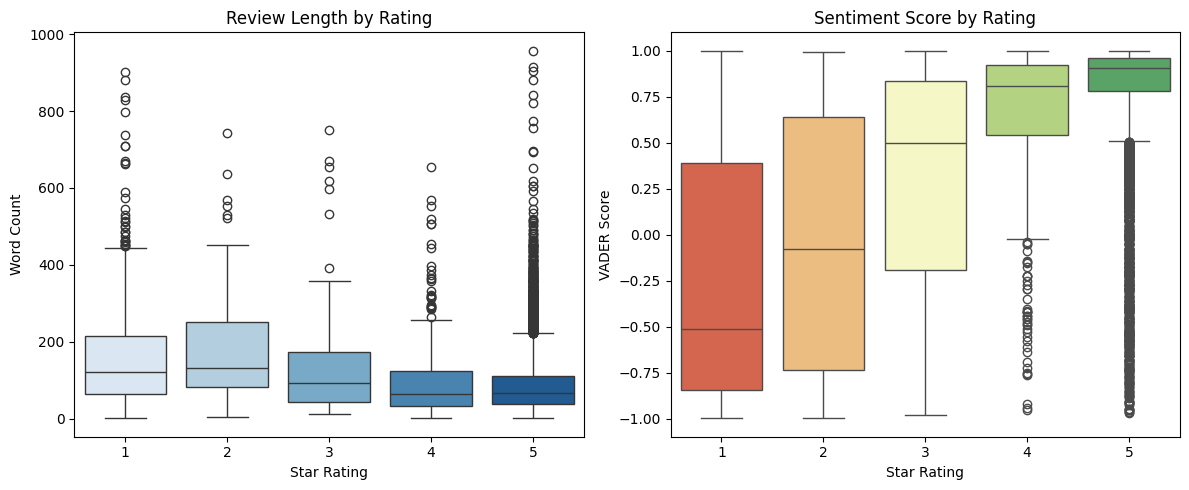

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x='rating', y='review_length', ax=axes[0], palette='Blues')
axes[0].set_title('Review Length by Rating')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Word Count')

sns.boxplot(data=df, x='rating', y='sentiment_score', ax=axes[1], palette='RdYlGn')
axes[1].set_title('Sentiment Score by Rating')
axes[1].set_xlabel('Star Rating')
axes[1].set_ylabel('VADER Score')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Final Project/Visualizations/boxplots.png', dpi=150)
plt.show()

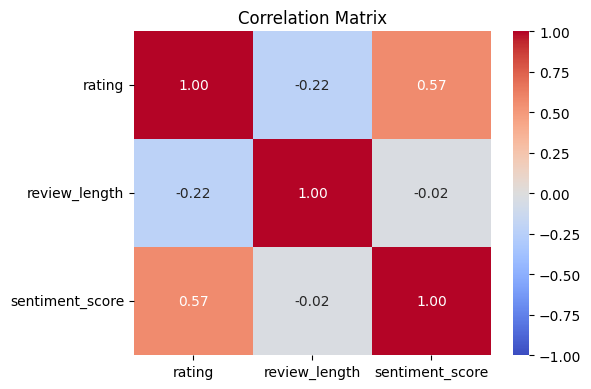

                 rating  review_length  sentiment_score
rating            1.000         -0.219            0.567
review_length    -0.219          1.000           -0.024
sentiment_score   0.567         -0.024            1.000


In [25]:
corr = df[['rating', 'review_length', 'sentiment_score']].corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Final Project/Visualizations/correlation_heatmap.png', dpi=150)
plt.show()
print(corr.round(3))

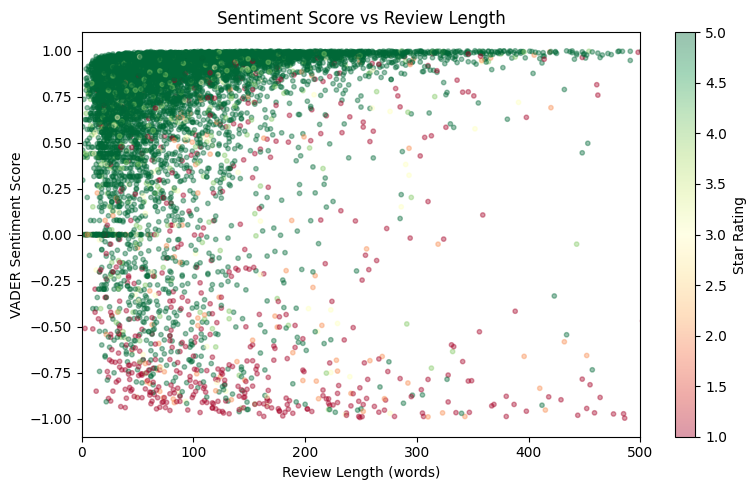

In [27]:
plt.figure(figsize=(8,5))
scatter = plt.scatter(df['review_length'], df['sentiment_score'],
                      c=df['rating'], cmap='RdYlGn', alpha=0.4, s=10)
plt.colorbar(scatter, label='Star Rating')
plt.title('Sentiment Score vs Review Length')
plt.xlabel('Review Length (words)')
plt.ylabel('VADER Sentiment Score')
plt.xlim(0, 500)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Final Project/Visualizations/scatter.png', dpi=150)
plt.show()